### 음성으로 감정 분류하기
1. 데이터 구조
   - 형식: WAV 음성 파일
   - 전체 샘플 수: 2023개
   - 감정별 분포:
     * 분노(Angry): 557개
     * 기쁨(Happy): 500개
     * 중립(Neutral): 399개
     * 슬픔(Sad): 567개

2. 파일명 규칙
   - 형식: [성별]-[감정][번호]-[카테고리]-[ID].wav
   - 예시: M-A3-C-001-0101.wav
     * M: 남성 화자
     * A: 분노 감정 (H: 기쁨, N: 중립, S: 슬픔)
     * 3: 버전 번호
     * C: 카테고리
     * 001-0101: 고유 식별자

3. 분류 클래스
   - 분노, 기쁨, 중립, 슬픔

#### 데이터 전처리
1. 파일명에서 라벨을 추출
2. 음성파일에서 특징을 잡아내는 방법

In [2]:
import os
import librosa
import numpy as np
import pandas as pd

In [70]:
#데이터 파일 경로 설정
data_path = './voice_data/'

file_names=[]

#파일명 리스트에 담기
for i in os.listdir(data_path):
  if i.endswith('.wav'):
    file_names.append(i)

#파일명에서 라벨 추출
def extract_label(file_name):
	parts = file_name.split('-')
	gender = parts[0]
	emotion = parts[1][0]
	unique_code = parts[-1].split('.')[0]
	return gender,emotion,unique_code

# 성별, 감정, 고유식별자 담을 리스트
info_list = []
#파일에서 정보 추출
for file_name in file_names:
	info = extract_label(file_name)
	if info:
			info_list.append(info)

# 데이터셋 생성
data = []
for file in file_names:
    label_info = extract_label(file)  # 성별, 감정, 고유 식별자 추출
    file_path = os.path.join(data_path, file)  # 파일 경로 생성
    data.append({'file_path': file_path, 'Gender': label_info[0], 'Emotion': label_info[1], 'Unique_code': label_info[2]})

#데이터 프레임 생성
df = pd.DataFrame(data)

In [71]:
df.head()

,file_path,Gender,Emotion,Unique_code
0,./voice_data/M-A3-C-001-0101.wav,M,A,0101
1,./voice_data/M-A3-C-001-0102.wav,M,A,0102
2,./voice_data/M-A3-C-001-0103.wav,M,A,0103
3,./voice_data/M-A3-C-001-0104.wav,M,A,0104
4,./voice_data/M-A3-C-001-0105.wav,M,A,0105


In [72]:
#Emotion 매핑해주기

emotion_map = {'A':'Angry', 'H':'Happy','N':'Nutral','S':'Sad'}

df['Emotion'] = df['Emotion'].map(emotion_map)

df.head()

,file_path,Gender,Emotion,Unique_code
0,./voice_data/M-A3-C-001-0101.wav,M,Angry,0101
1,./voice_data/M-A3-C-001-0102.wav,M,Angry,0102
2,./voice_data/M-A3-C-001-0103.wav,M,Angry,0103
3,./voice_data/M-A3-C-001-0104.wav,M,Angry,0104
4,./voice_data/M-A3-C-001-0105.wav,M,Angry,0105


### 시각화를 위한 데이터 추출 및 데이터프레임화 완료
1. info()로 데이터 확인
2. 시각화

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2023 entries, 0 to 2022
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   file_path    2023 non-null   object
 1   Gender       2023 non-null   object
 2   Emotion      2023 non-null   object
 3   Unique_code  2023 non-null   object
dtypes: object(4)
memory usage: 63.3+ KB


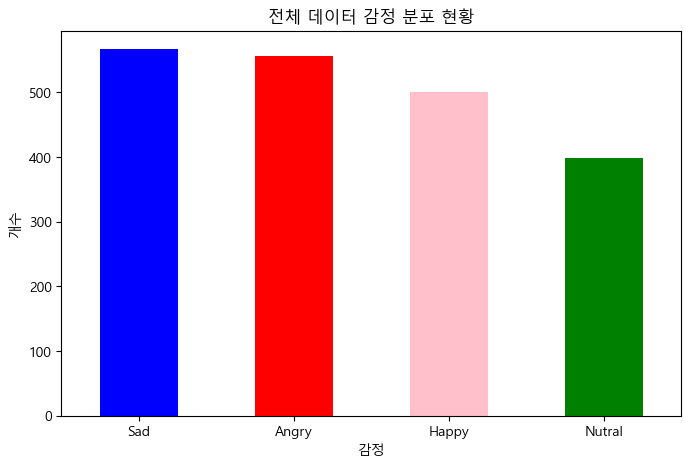

In [74]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False


# 전체 감정 분포 계산
emotion_distribution = df['Emotion'].value_counts()

# 전체 감정 분포 시각화
plt.figure(figsize=(8, 5))
emotion_distribution.plot(kind='bar', color=['blue', 'red', 'pink', 'green'])
plt.title('전체 데이터 감정 분포 현황')
plt.xlabel('감정')
plt.ylabel('개수')
plt.xticks(rotation=0)
plt.show()

In [75]:
df['Emotion'].value_counts()

Emotion
Sad       567
Angry     557
Happy     500
Nutral    399
Name: count, dtype: int64

In [76]:
df['Gender'].value_counts()

Gender
M    2023
Name: count, dtype: int64

#### 전체 데이터가 남성이라서 성별에 따른 데이터 분포 시각화는 생략

#### 음성 데이터 시각화 librosa

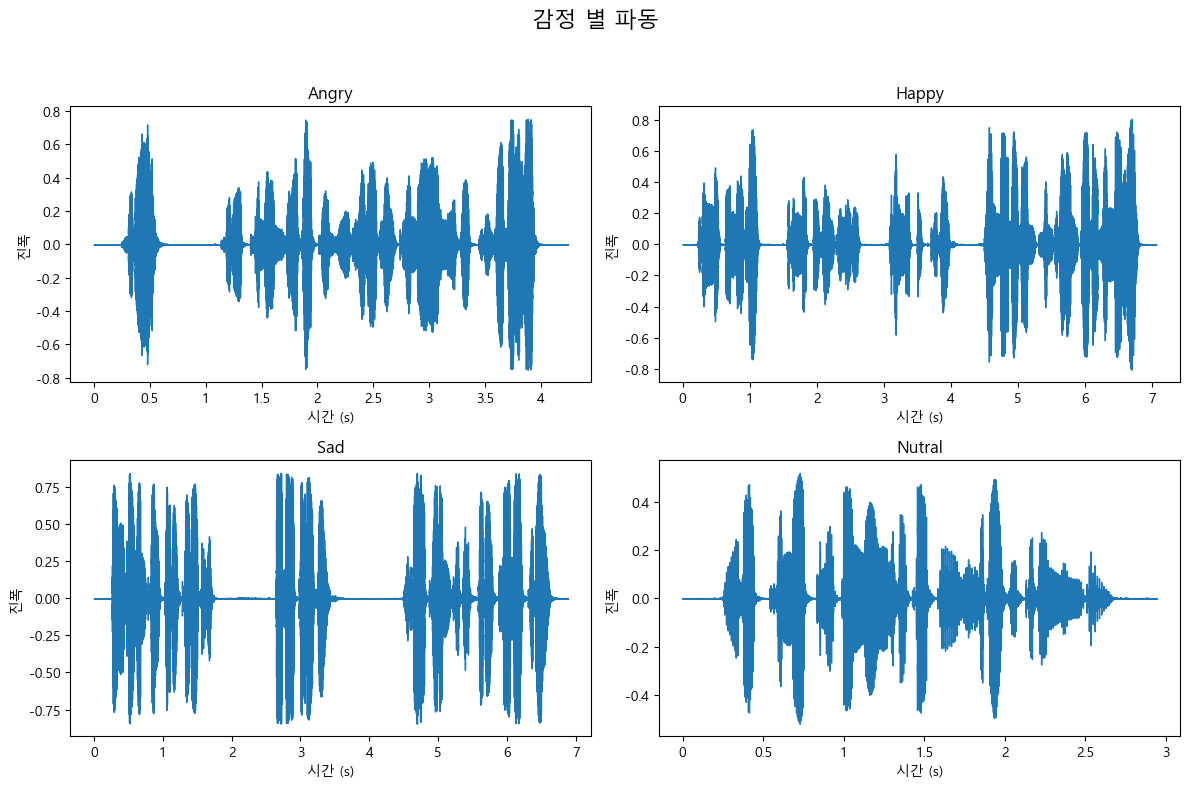

In [77]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# 시각화를 위한 감정 별 음성 파일 로드
file_paths = {'Angry':'./voice_data/M-A3-C-001-0101.wav',
             'Happy':'./voice_data/M-H3-C-001-0101.wav',
             'Sad':'./voice_data/M-S3-C-001-0101.wav',
             'Nutral':'./voice_data/M-NX-C-001-0101.wav'
             }

# 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('감정 별 파동', fontsize=16)

# 감정별 음성 파형 그리기
for ax, (emotion, file_path) in zip(axes.flatten(), file_paths.items()):
    # 음성 파일 로드
    try:
        y, sr = librosa.load(file_path)
        librosa.display.waveshow(y, sr=sr, ax=ax)
        ax.set_title(emotion)
        ax.set_xlabel('시간 (s)')
        ax.set_ylabel('진폭')
    except FileNotFoundError:
        ax.set_title(f"{emotion} (File Not Found)")
        ax.axis('off')

# 레이아웃 조정 및 출력
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [78]:
# 음성 데이터 전처리 [정규화]
def preprocess_audio(file_path):
    audio, sr = librosa.load(file_path, sr=22050)
    audio = librosa.util.normalize(audio)
    return audio

df['audio'] = df['file_path'].apply(preprocess_audio)

In [79]:
#음성 데이터에서 특성 추출
# MFCC 추출 함수 정의
def extract_features(audio, sr=22050):
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)  # 40개의 MFCC 계수 추출
    return np.mean(mfccs.T, axis=0)  # 시간 축에 대해 평균값 계산

# 데이터프레임에 MFCC 특징 추가
df['features'] = df['audio'].apply(lambda x: extract_features(x))

In [80]:
#특징 벡터를 배열로
X = np.array(df['features'].tolist())  # 모든 특징 벡터를 NumPy 배열로 변환
y = np.array(df['Emotion'].tolist())  # 감정 라벨을 NumPy 배열로 변환

In [81]:
df.head()

,file_path,Gender,Emotion,Unique_code,audio,features
0,./voice_data/M-A3-C-001-0101.wav,M,Angry,0101,"[-0.00021118009, -0.00030441876, -0.0002725991...","[-259.16553, 79.87538, -13.504722, 32.225597, ..."
1,./voice_data/M-A3-C-001-0102.wav,M,Angry,0102,"[0.00027067616, 0.00041243053, 0.00038960917, ...","[-230.00215, 75.2523, -20.765657, 26.700716, -..."
2,./voice_data/M-A3-C-001-0103.wav,M,Angry,0103,"[4.0292136e-05, 1.5881948e-05, -4.9988994e-06,...","[-229.77158, 61.946407, -15.388544, 28.594303,..."
3,./voice_data/M-A3-C-001-0104.wav,M,Angry,0104,"[-9.781569e-05, -6.553976e-05, -8.949262e-05, ...","[-263.54797, 87.73107, -18.438654, 16.107677, ..."
4,./voice_data/M-A3-C-001-0105.wav,M,Angry,0105,"[-8.666776e-05, -0.00013490638, -0.00011120766...","[-252.54028, 82.877716, -17.478388, 24.008684,..."


### 라벨 인코딩

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 라벨 인코딩
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# 인코딩 결과 확인
print("Encoded Labels:", y_encoded)
print("Label Classes:", encoder.classes_)  # ['Angry': 0, 'Happy' : 1, 'Neutral' :2 , 'Sad' : 3]

Encoded Labels: [0 0 0 ... 3 3 3]
Label Classes: ['Angry' 'Happy' 'Nutral' 'Sad']


In [83]:
from sklearn.model_selection import train_test_split

# 학습 데이터와 테스트 데이터 분할 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=44)

In [84]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 신경망 모델 설계
model = Sequential([
    Dense(128, activation='relu', input_shape=(X.shape[1],)),  # 입력 크기: 특징 벡터 크기 (n_mfcc=40)
    Dropout(0.3),  # 과적합 방지용 드롭아웃
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(encoder.classes_), activation='softmax')  # 출력 크기: 클래스 수 (4개 감정)
])

# 모델 컴파일
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [85]:
# 모델 학습
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/30
51/51 [==============================] - 1s 6ms/step - loss: 16.0653 - accuracy: 0.3152 - val_loss: 1.5542 - val_accuracy: 0.6667
Epoch 2/30
51/51 [==============================] - 0s 2ms/step - loss: 3.8013 - accuracy: 0.4710 - val_loss: 0.6566 - val_accuracy: 0.6815
Epoch 3/30
51/51 [==============================] - 0s 2ms/step - loss: 1.8554 - accuracy: 0.5272 - val_loss: 0.6443 - val_accuracy: 0.7728
Epoch 4/30
51/51 [==============================] - 0s 2ms/step - loss: 1.2466 - accuracy: 0.5803 - val_loss: 0.5745 - val_accuracy: 0.8247
Epoch 5/30
51/51 [==============================] - 0s 2ms/step - loss: 0.9144 - accuracy: 0.6607 - val_loss: 0.4619 - val_accuracy: 0.8642
Epoch 6/30
51/51 [==============================] - 0s 2ms/step - loss: 0.7181 - accuracy: 0.7386 - val_loss: 0.3187 - val_accuracy: 0.9481
Epoch 7/30
51/51 [==============================] - 0s 2ms/step - loss: 0.6159 - accuracy: 0.7701 - val_loss: 0.2487 - val_accuracy: 0.9556
Epoch 8/30
51/51 [=

In [86]:
# 모델 평가
evaluation = model.evaluate(X_test, y_test)
print("Test Loss:", evaluation[0])
print("Test Accuracy:", evaluation[1])

13/13 [==============================] - 0s 834us/step - loss: 0.0055 - accuracy: 0.9975
Test Loss: 0.005491766147315502
Test Accuracy: 0.9975308775901794


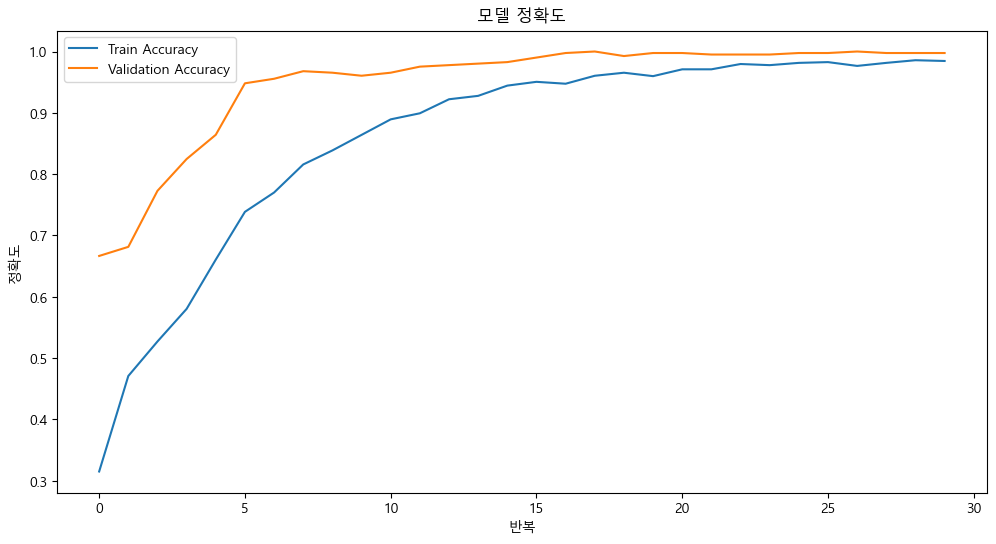

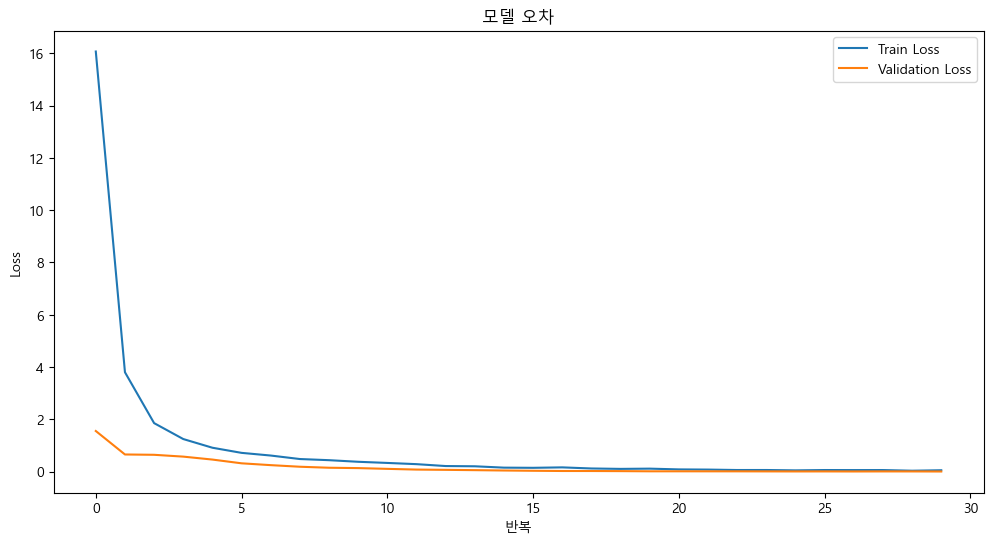

In [88]:
import matplotlib.pyplot as plt

# 정확도 시각화
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('모델 정확도')
plt.xlabel('반복')
plt.ylabel('정확도')
plt.legend()
plt.show()

# 손실 시각화
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('모델 오차')
plt.xlabel('반복')
plt.ylabel('Loss')
plt.legend()
plt.show()


### 새로운 음성파일로 테스트 해보자!

In [ ]:
# 새로운 음성 파일 경로 설정
new_audio_path = './voice_data/new_audio.wav'

# 음성 데이터 전처리
def preprocess_audio(file_path):
    audio, sr = librosa.load(file_path, sr=22050)
    audio = librosa.util.normalize(audio)
    return audio

new_audio = preprocess_audio(new_audio_path)

# 특징 추출
def extract_features(audio, sr=22050):
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    return np.mean(mfccs.T, axis=0)

new_features = extract_features(new_audio)

# 입력 형태 변환 및 예측 수행
new_features = np.expand_dims(new_features, axis=0)
predicted_class = model.predict(new_features)
predicted_label = encoder.inverse_transform([np.argmax(predicted_class)])

print(f"Predicted Emotion: {predicted_label[0]}")